# Numerical Prediction — Non-Temporal Approach

This notebook applies regression models to predict the **next-day mean mood** as a
continuous value (Task 4 — non-temporal part).

The engineered feature datasets are produced by
`1c_feature_engineering_non_temporal/feature_engineering.ipynb` for each candidate window size.

## Pipeline overview
1. Load train / val / test splits for **all window sizes**
2. Preprocessing: median imputation per window size
3. **Cross-window training** — for each window size, train and tune all models on train, score on val
4. **Model selection** — pick best (window size, model, hyperparameters) by val RMSE
5. **Final test** — retrain best model on train + val; evaluate once on held-out test set
6. Report: residual analysis, feature importances, comparison with classification results

## Models
| Model | Role |
|---|---|
| **MoodLag1** | Predict yesterday's mood — zero-cost baseline |
| **Ridge Regression** | Linear model; L2 regularisation + scaling |
| **Random Forest** | Tuned; captures non-linear feature interactions |
| **Hist. Gradient Boosting** | Tuned; handles NaN natively |


In [13]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

DATA_DIR = Path("../1c_feature_engineering_non_temporal/output")
WINDOW_SIZES = [1, 3, 5, 7, 14]
META_COLS = ["id", "target_date", "target_mood"]


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

---
## 1. Load data for all window sizes

In [14]:
data = {}  # ws -> {"train": df, "val": df, "test": df}

for ws in WINDOW_SIZES:
    try:
        train_raw = pd.read_parquet(DATA_DIR / f"train_w{ws}.parquet")
        val_raw = pd.read_parquet(DATA_DIR / f"val_w{ws}.parquet")
        test_raw = pd.read_parquet(DATA_DIR / f"test_w{ws}.parquet")
        data[ws] = {"train": train_raw, "val": val_raw, "test": test_raw}
        feat_cols = [c for c in train_raw.columns if c not in META_COLS]
        print(
            f"w={ws:>2}d  train={len(train_raw):>4}  val={len(val_raw):>4}"
            f"  test={len(test_raw):>4}  features={len(feat_cols)}"
        )
    except FileNotFoundError:
        print(f"w={ws:>2}d  NOT FOUND — run feature_engineering.ipynb first")

print(f"\nLoaded window sizes: {sorted(data.keys())}")

w= 1d  train= 858  val= 136  test= 265  features=130
w= 3d  train= 864  val= 136  test= 268  features=132
w= 5d  train= 864  val= 136  test= 268  features=134
w= 7d  train= 864  val= 136  test= 268  features=136
w=14d  train= 864  val= 136  test= 268  features=143

Loaded window sizes: [1, 3, 5, 7, 14]


---
## 2. Preprocessing

**Imputation:** ~7 % of feature values are missing (lag features early in a patient's
observation period, sparse app-category features). We apply **median imputation** fitted on
the training split only.

The target `target_mood` is used as-is (continuous, 1–10 scale) — no discretisation.

**Scaling:** applied inside the Ridge pipeline only. Tree-based models are scale-invariant.

**Leakage prevention:** imputer, scaler, and `PredefinedSplit` indices are all derived from
the training split. The val split is only used for scoring; the test split is never seen
until final evaluation.

In [15]:
preprocessed = {}  # ws -> dict of arrays + targets + PredefinedSplit

for ws, splits in data.items():
    feat_cols = [c for c in splits["train"].columns if c not in META_COLS]

    X_train_raw = splits["train"][feat_cols].values
    X_val_raw = splits["val"][feat_cols].values
    X_test_raw = splits["test"][feat_cols].values

    y_train = splits["train"]["target_mood"].values
    y_val = splits["val"]["target_mood"].values
    y_test = splits["test"]["target_mood"].values

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train_raw)
    X_val = imputer.transform(X_val_raw)
    X_test = imputer.transform(X_test_raw)

    X_trainval = np.vstack([X_train, X_val])
    y_trainval = np.concatenate([y_train, y_val])
    split_idx = [-1] * len(X_train) + [0] * len(X_val)

    # MoodLag1 feature index (used for the lag baseline)
    lag1_idx = feat_cols.index("mood_lag1") if "mood_lag1" in feat_cols else None

    preprocessed[ws] = {
        "feat_cols": feat_cols,
        "imputer": imputer,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "X_train_raw": X_train_raw,
        "X_val_raw": X_val_raw,
        "X_test_raw": X_test_raw,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "X_trainval": X_trainval,
        "y_trainval": y_trainval,
        "pre_split": PredefinedSplit(test_fold=split_idx),
        "lag1_idx": lag1_idx,
    }

print("Preprocessing complete for all window sizes.")
print(f"Post-imputation NaN check (w=7): {np.isnan(preprocessed[7]['X_train']).sum()}")

Preprocessing complete for all window sizes.
Post-imputation NaN check (w=7): 0


---
## 3. Evaluation setup

### Metric: RMSE (primary) and MAE (secondary)

RMSE (Root Mean Squared Error) is the primary metric:
- It is in the same units as the target (mood points on a 1–10 scale), making it
  directly interpretable.
- It penalises large errors more than MAE, which matters clinically — badly missed
  days are more harmful than small constant offsets.

MAE (Mean Absolute Error) is reported alongside RMSE as a robustness check:
if RMSE ≫ MAE, the model has occasional large errors despite being generally close.

R² is also reported on the test set for interpretability.

### Selection process
1. For each window size: train MoodLag1 baseline, Ridge, tuned Random Forest, tuned HistGBR
2. Compare all (window size, model) combos by **val RMSE** (lower is better)
3. Retrain the winner on train + val → evaluate **once** on the held-out test set

### Why not random cross-validation
Same reason as in the classification notebook: the dataset contains repeated observations
from 27 patients, so random k-fold causes temporal leakage. `PredefinedSplit` is used
for all hyperparameter searches.

In [16]:
RF_PARAM_DIST = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
}

HGB_PARAM_DIST = {
    "max_iter": [100, 200, 300],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "min_samples_leaf": [10, 20, 30],
    "l2_regularization": [0.0, 0.1, 1.0],
}

print("Hyperparameter search spaces defined.")

Hyperparameter search spaces defined.


---
## 4. Cross-window model training

### MoodLag1 baseline
Predicts tomorrow's mood as today's mood (`mood_lag1`). This is a strong zero-cost
baseline because mood is highly autocorrelated. Any learned model must beat it to be
useful.

### Ridge Regression
A linear model with L2 regularisation. Represents the best achievable performance
from a *linear* combination of the 136 engineered features. Fast, interpretable,
and a good indicator of linear signal in the data.

### Random Forest Regressor
Captures non-linear interactions (e.g. mood lag × social app usage). 80-iteration
randomised hyperparameter search with `PredefinedSplit` scored by neg-RMSE.

### Hist. Gradient Boosting Regressor
sklearn's efficient gradient boosting implementation. Handles NaN natively so no
imputation is needed. Acts as a sanity check against Random Forest.

In [17]:
all_val_results = []  # list of dicts: window_size, model, rmse, mae
fitted_models = {}  # (ws, model_name) -> fitted model (trained on train only)
best_rf_params = {}  # ws -> best RF params
best_hgb_params = {}  # ws -> best HGB params

for ws in sorted(preprocessed.keys()):
    pp = preprocessed[ws]
    y_train = pp["y_train"]
    y_val = pp["y_val"]

    print(f"\n{'=' * 65}")
    print(f" Window = {ws} days  |  train={len(y_train)}  val={len(y_val)}")
    print(f"{'=' * 65}")

    def _record(model_name, y_pred):
        r = {
            "window_size": ws,
            "model": model_name,
            "rmse": round(rmse(y_val, y_pred), 4),
            "mae": round(mean_absolute_error(y_val, y_pred), 4),
        }
        all_val_results.append(r)
        print(f"  {model_name:50s}  RMSE={r['rmse']:.4f}  MAE={r['mae']:.4f}")

    # ── MoodLag1 baseline ────────────────────────────────────────────────────
    if pp["lag1_idx"] is not None:
        lag_median = np.nanmedian(pp["X_train_raw"][:, pp["lag1_idx"]])
        lag_pred_val = np.where(
            np.isnan(pp["X_val_raw"][:, pp["lag1_idx"]]),
            lag_median,
            pp["X_val_raw"][:, pp["lag1_idx"]],
        )
        _record("MoodLag1 (baseline)", lag_pred_val)
        fitted_models[(ws, "MoodLag1 (baseline)")] = {
            "lag1_idx": pp["lag1_idx"],
            "lag_median": lag_median,
        }

    # ── Ridge Regression ────────────────────────────────────────────────────
    ridge = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    )
    ridge.fit(pp["X_train_raw"], y_train)
    _record("Ridge Regression", ridge.predict(pp["X_val_raw"]))
    fitted_models[(ws, "Ridge Regression")] = ridge

    # ── Random Forest (tuned) ────────────────────────────────────────────────
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE),
        param_distributions=RF_PARAM_DIST,
        n_iter=80,
        cv=pp["pre_split"],
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=False,
        verbose=0,
    )
    rf_search.fit(pp["X_trainval"], pp["y_trainval"])
    best_rf_params[ws] = rf_search.best_params_
    rf = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE)
    rf.fit(pp["X_train"], y_train)
    _record("Random Forest (tuned)", rf.predict(pp["X_val"]))
    fitted_models[(ws, "Random Forest (tuned)")] = rf

    # ── Hist. Gradient Boosting (tuned) ──────────────────────────────────────
    hgb_search = RandomizedSearchCV(
        HistGradientBoostingRegressor(random_state=RANDOM_STATE),
        param_distributions=HGB_PARAM_DIST,
        n_iter=80,
        cv=pp["pre_split"],
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=False,
        verbose=0,
    )
    hgb_search.fit(pp["X_trainval"], pp["y_trainval"])
    best_hgb_params[ws] = hgb_search.best_params_
    hgb = HistGradientBoostingRegressor(
        **hgb_search.best_params_, random_state=RANDOM_STATE
    )
    hgb.fit(pp["X_train"], y_train)
    _record("Hist. Gradient Boosting (tuned)", hgb.predict(pp["X_val"]))
    fitted_models[(ws, "Hist. Gradient Boosting (tuned)")] = hgb

print("\nTraining complete.")


 Window = 1 days  |  train=858  val=136
  MoodLag1 (baseline)                                 RMSE=0.6134  MAE=0.4763
  Ridge Regression                                    RMSE=0.7167  MAE=0.5807
  Random Forest (tuned)                               RMSE=0.6534  MAE=0.5402
  Hist. Gradient Boosting (tuned)                     RMSE=0.6557  MAE=0.5374

 Window = 3 days  |  train=864  val=136
  MoodLag1 (baseline)                                 RMSE=0.6134  MAE=0.4763
  Ridge Regression                                    RMSE=0.6235  MAE=0.4947
  Random Forest (tuned)                               RMSE=0.5957  MAE=0.4925
  Hist. Gradient Boosting (tuned)                     RMSE=0.5966  MAE=0.4911

 Window = 5 days  |  train=864  val=136
  MoodLag1 (baseline)                                 RMSE=0.6134  MAE=0.4763
  Ridge Regression                                    RMSE=0.7263  MAE=0.5473
  Random Forest (tuned)                               RMSE=0.5471  MAE=0.4140
  Hist. Gradient Bo

---
## 5. Validation results — all window sizes × models

In [18]:
val_df = (
    pd.DataFrame(all_val_results)
    .sort_values(["rmse", "window_size"], ascending=[True, True])
    .reset_index(drop=True)
)
print("=== Validation results (sorted by RMSE, lower is better) ===")
print(val_df.to_string(index=False))

# Pivot for quick overview
pivot = val_df.pivot(index="model", columns="window_size", values="rmse")
print("\n=== Val RMSE by model × window size ===")
print(pivot.round(4).to_string())

best_row = val_df.iloc[0]
BEST_WS = int(best_row["window_size"])
BEST_MODEL = best_row["model"]
print(
    f"\n>>> Best: window={BEST_WS}d  |  model={BEST_MODEL}  |  val RMSE={best_row['rmse']:.4f}"
)

=== Validation results (sorted by RMSE, lower is better) ===
 window_size                           model   rmse    mae
           5 Hist. Gradient Boosting (tuned) 0.5368 0.4211
           5           Random Forest (tuned) 0.5471 0.4140
           7 Hist. Gradient Boosting (tuned) 0.5553 0.4344
           7           Random Forest (tuned) 0.5925 0.4873
           3           Random Forest (tuned) 0.5957 0.4925
           3 Hist. Gradient Boosting (tuned) 0.5966 0.4911
          14 Hist. Gradient Boosting (tuned) 0.6084 0.4994
           1             MoodLag1 (baseline) 0.6134 0.4763
           3             MoodLag1 (baseline) 0.6134 0.4763
           5             MoodLag1 (baseline) 0.6134 0.4763
           7             MoodLag1 (baseline) 0.6134 0.4763
          14             MoodLag1 (baseline) 0.6134 0.4763
           3                Ridge Regression 0.6235 0.4947
          14           Random Forest (tuned) 0.6300 0.5181
           1           Random Forest (tuned) 0.6534 0.

---
## 6. Final evaluation on the test set

The best (window size, model) is retrained on **train + val combined**, then evaluated
**once** on the held-out test set. The test set has not been seen during any selection step.

In [19]:
pp = preprocessed[BEST_WS]
y_trainval = pp["y_trainval"]
y_test = pp["y_test"]

print(f"Retraining '{BEST_MODEL}' on train+val (window={BEST_WS}d)...")

if BEST_MODEL == "MoodLag1 (baseline)":
    lag_median_final = np.nanmedian(
        np.concatenate(
            [pp["X_train_raw"][:, pp["lag1_idx"]], pp["X_val_raw"][:, pp["lag1_idx"]]]
        )
    )
    y_test_pred = np.where(
        np.isnan(pp["X_test_raw"][:, pp["lag1_idx"]]),
        lag_median_final,
        pp["X_test_raw"][:, pp["lag1_idx"]],
    )
    final_model = None  # not a sklearn estimator

elif BEST_MODEL == "Ridge Regression":
    X_tv = np.vstack([pp["X_train_raw"], pp["X_val_raw"]])
    final_model = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0)),
        ]
    )
    final_model.fit(X_tv, y_trainval)
    y_test_pred = final_model.predict(pp["X_test_raw"])

elif BEST_MODEL == "Random Forest (tuned)":
    final_model = RandomForestRegressor(
        **best_rf_params[BEST_WS], random_state=RANDOM_STATE
    )
    final_model.fit(pp["X_trainval"], y_trainval)
    y_test_pred = final_model.predict(pp["X_test"])

elif BEST_MODEL == "Hist. Gradient Boosting (tuned)":
    final_model = HistGradientBoostingRegressor(
        **best_hgb_params[BEST_WS], random_state=RANDOM_STATE
    )
    final_model.fit(pp["X_trainval"], y_trainval)
    y_test_pred = final_model.predict(pp["X_test"])

test_rmse = rmse(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\n{'=' * 60}")
print(f" {BEST_MODEL}  (window={BEST_WS}d) — TEST SET")
print(f"{'=' * 60}")
print(f"RMSE : {test_rmse:.4f}  (mood points)")
print(f"MAE  : {test_mae:.4f}  (mood points)")
print(f"R²   : {test_r2:.4f}")

Retraining 'Hist. Gradient Boosting (tuned)' on train+val (window=5d)...

 Hist. Gradient Boosting (tuned)  (window=5d) — TEST SET
RMSE : 0.5751  (mood points)
MAE  : 0.4238  (mood points)
R²   : 0.2364


---
## 7. Residual analysis

Residual plots reveal *how* the model fails:
- **Predicted vs. actual**: ideal model lies on the diagonal.
- **Residuals vs. predicted**: should be centred at zero with no trend (homoscedasticity).
- **Residual histogram**: checks whether errors are approximately normal.

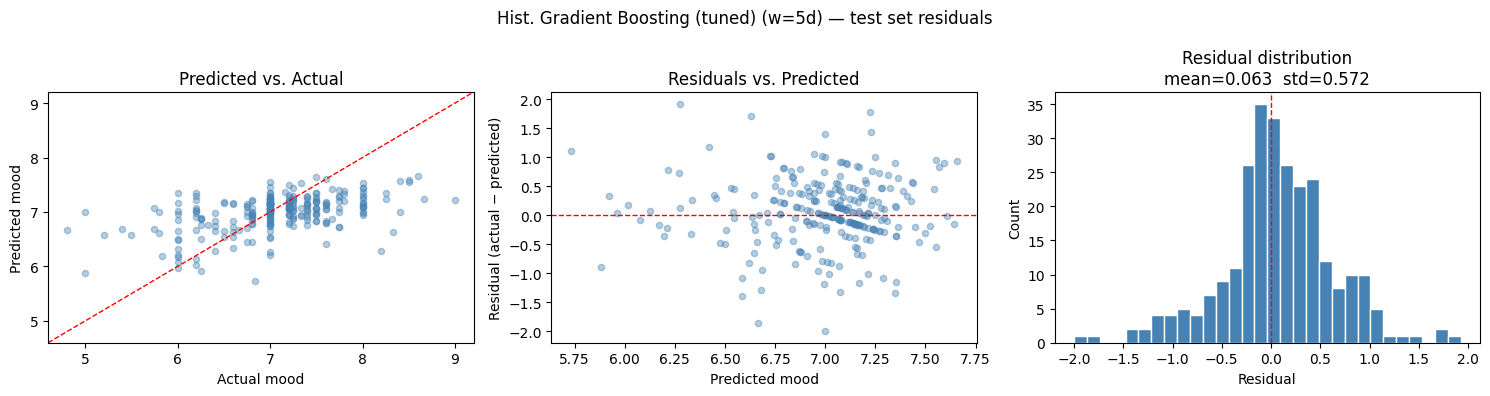

Saved: residuals.png


In [20]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Predicted vs. actual
ax = axes[0]
ax.scatter(y_test, y_test_pred, alpha=0.4, s=20, color="steelblue")
lims = [
    min(y_test.min(), y_test_pred.min()) - 0.2,
    max(y_test.max(), y_test_pred.max()) + 0.2,
]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual mood")
ax.set_ylabel("Predicted mood")
ax.set_title("Predicted vs. Actual")
ax.set_xlim(lims)
ax.set_ylim(lims)

# 2. Residuals vs. predicted
ax = axes[1]
ax.scatter(y_test_pred, residuals, alpha=0.4, s=20, color="steelblue")
ax.axhline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Predicted mood")
ax.set_ylabel("Residual (actual − predicted)")
ax.set_title("Residuals vs. Predicted")

# 3. Residual histogram
ax = axes[2]
ax.hist(residuals, bins=30, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("Residual")
ax.set_ylabel("Count")
ax.set_title(
    f"Residual distribution\nmean={residuals.mean():.3f}  std={residuals.std():.3f}"
)

plt.suptitle(f"{BEST_MODEL} (w={BEST_WS}d) — test set residuals", fontsize=12)
plt.tight_layout()
plt.savefig("residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: residuals.png")

---
## 8. Feature importances (Random Forest)

In [21]:
if final_model is not None and hasattr(final_model, "feature_importances_"):
    feat_cols = preprocessed[BEST_WS]["feat_cols"]
    feat_imp_df = (
        pd.DataFrame(
            {"feature": feat_cols, "importance": final_model.feature_importances_}
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    print("Top 20 most important features:")
    print(feat_imp_df.head(20).to_string(index=False))

    top_n = 25
    fig, ax = plt.subplots(figsize=(8, 8))
    feat_imp_df.head(top_n).sort_values("importance").plot(
        kind="barh", x="feature", y="importance", ax=ax, legend=False, color="steelblue"
    )
    ax.set_xlabel("Mean decrease in impurity")
    ax.set_title(f"Top {top_n} feature importances — {BEST_MODEL} (w={BEST_WS}d)")
    plt.tight_layout()
    plt.savefig("feature_importances_regression.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: feature_importances_regression.png")
else:
    print(f"Feature importances not available for {BEST_MODEL}.")

Feature importances not available for Hist. Gradient Boosting (tuned).


---
## 9. Summary table

In [22]:
print("=== Val RMSE leaderboard (all window sizes × models) ===")
print(val_df.to_string(index=False))

print(f"\n>>> Selected: window={BEST_WS}d  |  {BEST_MODEL}")
print(f"    Val RMSE  : {best_row['rmse']:.4f}")
print(f"    Test RMSE : {test_rmse:.4f}")
print(f"    Test MAE  : {test_mae:.4f}")
print(f"    Test R²   : {test_r2:.4f}")

=== Val RMSE leaderboard (all window sizes × models) ===
 window_size                           model   rmse    mae
           5 Hist. Gradient Boosting (tuned) 0.5368 0.4211
           5           Random Forest (tuned) 0.5471 0.4140
           7 Hist. Gradient Boosting (tuned) 0.5553 0.4344
           7           Random Forest (tuned) 0.5925 0.4873
           3           Random Forest (tuned) 0.5957 0.4925
           3 Hist. Gradient Boosting (tuned) 0.5966 0.4911
          14 Hist. Gradient Boosting (tuned) 0.6084 0.4994
           1             MoodLag1 (baseline) 0.6134 0.4763
           3             MoodLag1 (baseline) 0.6134 0.4763
           5             MoodLag1 (baseline) 0.6134 0.4763
           7             MoodLag1 (baseline) 0.6134 0.4763
          14             MoodLag1 (baseline) 0.6134 0.4763
           3                Ridge Regression 0.6235 0.4947
          14           Random Forest (tuned) 0.6300 0.5181
           1           Random Forest (tuned) 0.6534 0.5402

---
## 10. Discussion

### Regression vs. classification

**Regression** predicts the raw continuous mood score (1–10 scale). The RMSE gives a
direct sense of prediction error in mood-point units. A model with RMSE ≈ 0.5 is
off by about half a mood point on average — clinically, that corresponds to a near-miss
on the questionnaire scale.

**Classification** (Task 2A) discretises mood into Low / Medium / High and optimises
macro F1. It is less sensitive to fine-grained numerical errors but better at identifying
days that truly fall in a different wellbeing category. The two tasks are complementary:
- Classification is easier to communicate ("tomorrow looks like a low-mood day")
  and robust to small label noise.
- Regression preserves the full distribution of predictions, useful for ranking or
  risk-scoring across patients.

### MoodLag1 baseline
The lag-1 baseline is surprisingly competitive because mood is strongly autocorrelated
(yesterday's mood is the single best predictor of today's mood). Any learned model must
outperform this simple heuristic to justify its added complexity.

### Model comparison
- **Ridge Regression** quantifies how much linear signal is present in the engineered
  features. If Ridge beats MoodLag1, the additional features contain useful linear signal.
- **Random Forest / HistGBR** can exploit non-linear interactions and typically reduce
  RMSE further. If they substantially beat Ridge, non-linearities are important.

### Window size
Shorter windows capture recency; longer windows expose trend and weekly patterns.
The optimal window reflects a trade-off: too short misses weekly periodicity, too long
dilutes the recent signal with older data.

### Limitations
- Small dataset (≈700 training instances, 27 patients): performance estimates have wide
  confidence intervals.
- Patient-level effects are not explicitly modelled; a mixed-effects regression may reduce
  the within-patient error.
- RMSE aggregates all patients; per-patient RMSE could reveal which patients are harder
  to predict.

### Reproducibility
All random operations use `RANDOM_STATE = 42`. Imputation is fitted on the training split
only. `PredefinedSplit` ensures no leakage during hyperparameter search. Run cells
top-to-bottom to reproduce all results.